# Loan Prediction – Advanced Data Exploration, Statistical Analysis & Feature Engineering
### AnalystLab Africa – Data Science Internship Programme
**Week 3: Advanced Data Exploration, Statistical Analysis & Feature Engineering**

Continuing from Week 2's cleaned Loan Prediction dataset (614 applications). This notebook covers
advanced EDA, statistical hypothesis testing, feature engineering, feature selection, and final
preparation of a machine-learning-ready dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452"]
pd.set_option("display.max_columns", None)


## Part 1 – Advanced Data Quality Assessment

Rebuilding the Week 2 cleaned dataset here so this notebook is self-contained, then reviewing
its quality before moving into deeper analysis.


In [2]:
df = pd.read_csv("../data/raw/loan_prediction_raw.csv")

df_clean = df.copy()
df_clean.drop(columns=["Loan_ID"], inplace=True)

for col in ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean["LoanAmount"] = df_clean["LoanAmount"].fillna(df_clean["LoanAmount"].median())
df_clean["Loan_Amount_Term"] = df_clean["Loan_Amount_Term"].fillna(df_clean["Loan_Amount_Term"].mode()[0])

df_clean["Dependents"] = df_clean["Dependents"].replace("3+", 3).astype(int)
df_clean["Credit_History"] = df_clean["Credit_History"].astype(int)

df_clean["TotalIncome"] = df_clean["ApplicantIncome"] + df_clean["CoapplicantIncome"]
df_clean.rename(columns={
    "ApplicantIncome": "Applicant_Income",
    "CoapplicantIncome": "Coapplicant_Income",
    "LoanAmount": "Loan_Amount",
}, inplace=True)

def cap_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

for col in ["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "TotalIncome"]:
    df_clean[col] = cap_outliers_iqr(df_clean[col])

print("Shape:", df_clean.shape)
df_clean.head()

Shape: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1,Urban,Y,6000.0


**Quality checks on the Week 2 cleaned dataset:**

In [3]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print()
print("Data types:")
print(df_clean.dtypes)

Missing values: 0
Duplicate rows: 1

Data types:
Gender                    str
Married                   str
Dependents              int64
Education                 str
Self_Employed             str
Applicant_Income      float64
Coapplicant_Income    float64
Loan_Amount           float64
Loan_Amount_Term      float64
Credit_History          int64
Property_Area             str
Loan_Status               str
TotalIncome           float64
dtype: object


**Class balance (target variable):**

In [4]:
class_counts = df_clean["Loan_Status"].value_counts()
class_pct = (class_counts / len(df_clean) * 100).round(1)
pd.DataFrame({"count": class_counts, "pct": class_pct})

,count,pct
Loan_Status,,
Y,422,68.7
N,192,31.3


## Part 2 – Advanced Exploratory Data Analysis

### Numerical Analysis

**1. Histogram – Total Income**

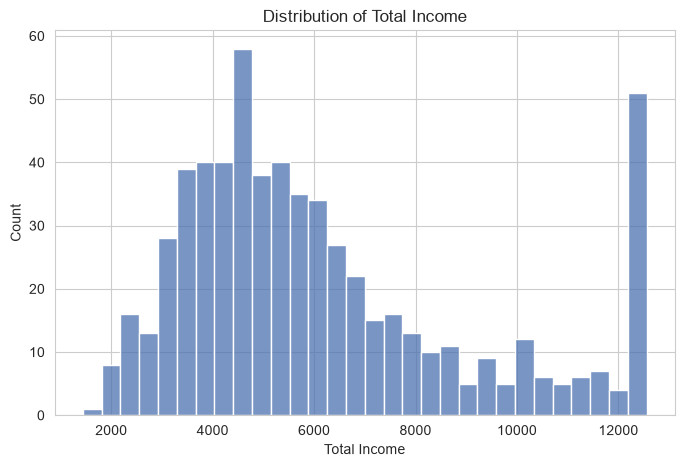

In [5]:
plt.figure()
sns.histplot(df_clean["TotalIncome"], bins=30, color=COLORS[0], kde=False)
plt.title("Distribution of Total Income")
plt.xlabel("Total Income")
plt.savefig("../visuals/01_hist_total_income.png", bbox_inches="tight")
plt.show()

**2. Histogram – Loan Amount**

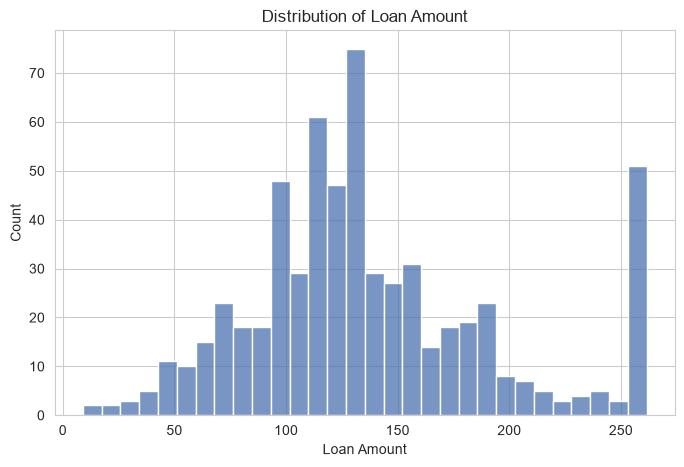

In [6]:
plt.figure()
sns.histplot(df_clean["Loan_Amount"], bins=30, color=COLORS[0])
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.savefig("../visuals/02_hist_loan_amount.png", bbox_inches="tight")
plt.show()

**3. Boxplot – Total Income**

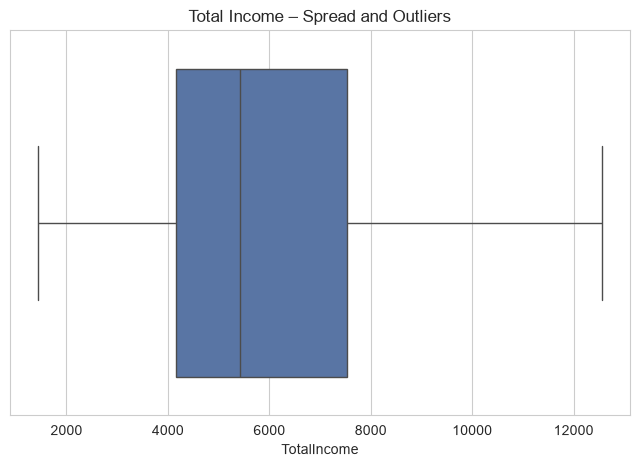

In [7]:
plt.figure()
sns.boxplot(x=df_clean["TotalIncome"], color=COLORS[0])
plt.title("Total Income – Spread and Outliers")
plt.savefig("../visuals/03_box_total_income.png", bbox_inches="tight")
plt.show()

**4. Boxplot – Loan Amount**

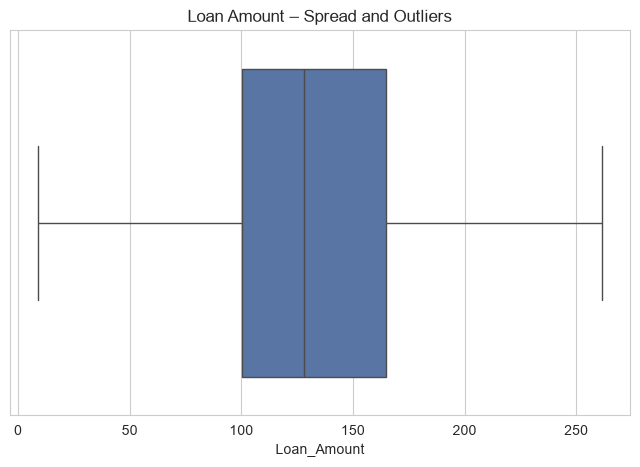

In [8]:
plt.figure()
sns.boxplot(x=df_clean["Loan_Amount"], color=COLORS[0])
plt.title("Loan Amount – Spread and Outliers")
plt.savefig("../visuals/04_box_loan_amount.png", bbox_inches="tight")
plt.show()

**5. Density Plot – Total Income**

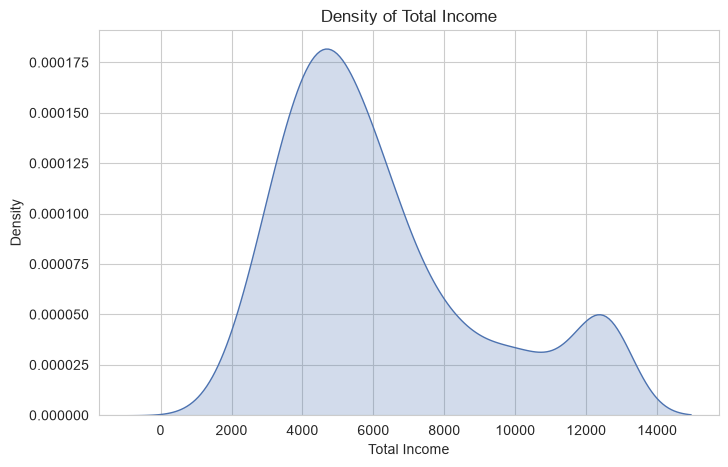

In [9]:
plt.figure()
sns.kdeplot(df_clean["TotalIncome"], fill=True, color=COLORS[0])
plt.title("Density of Total Income")
plt.xlabel("Total Income")
plt.savefig("../visuals/05_kde_total_income.png", bbox_inches="tight")
plt.show()

**6. Density Plot – Loan Amount**

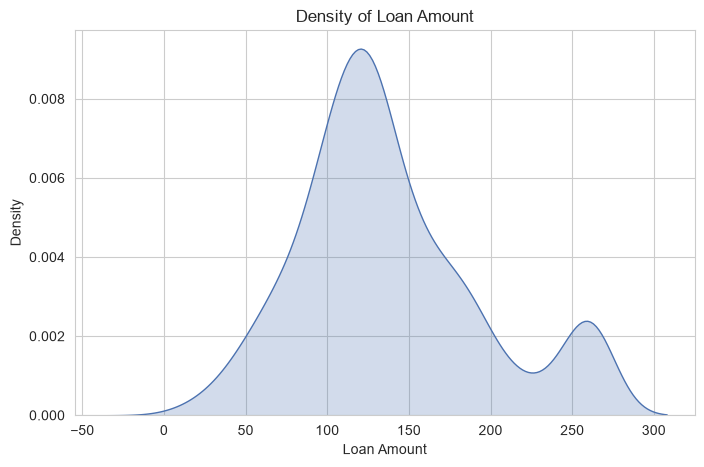

In [10]:
plt.figure()
sns.kdeplot(df_clean["Loan_Amount"], fill=True, color=COLORS[0])
plt.title("Density of Loan Amount")
plt.xlabel("Loan Amount")
plt.savefig("../visuals/06_kde_loan_amount.png", bbox_inches="tight")
plt.show()

### Categorical Analysis

**7-11. Frequency distributions of key categorical variables**

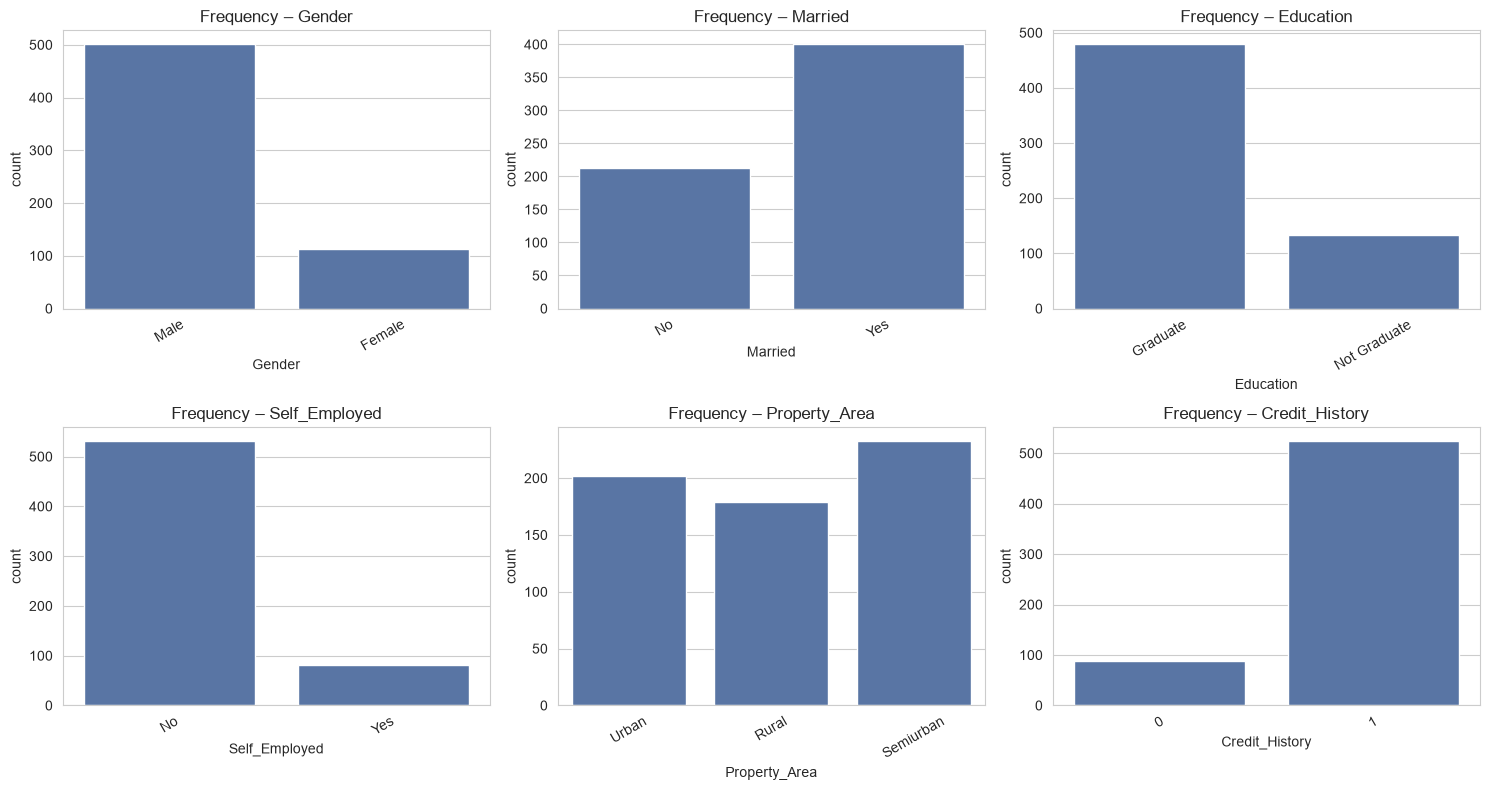

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat_cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Credit_History"]
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df_clean, x=col, ax=ax, color=COLORS[0])
    ax.set_title(f"Frequency – {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../visuals/07_categorical_frequencies.png", bbox_inches="tight")
plt.show()

**12. Cross-tabulation (%) – Gender vs Loan Status**

Loan_Status     N     Y
Gender                 
Female       33.0  67.0
Male         30.9  69.1


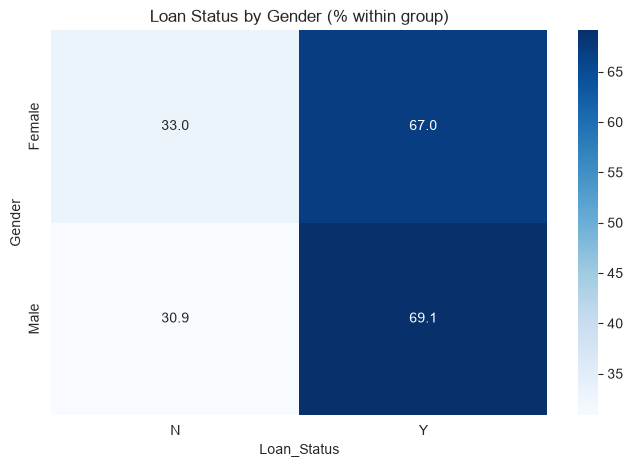

In [12]:
ct_gender = pd.crosstab(df_clean["Gender"], df_clean["Loan_Status"], normalize="index") * 100
print(ct_gender.round(1))

plt.figure()
sns.heatmap(ct_gender, annot=True, fmt=".1f", cmap="Blues")
plt.title("Loan Status by Gender (% within group)")
plt.savefig("../visuals/08_crosstab_gender.png", bbox_inches="tight")
plt.show()

**13. Cross-tabulation (%) – Property Area vs Loan Status**

Loan_Status       N     Y
Property_Area            
Rural          38.5  61.5
Semiurban      23.2  76.8
Urban          34.2  65.8


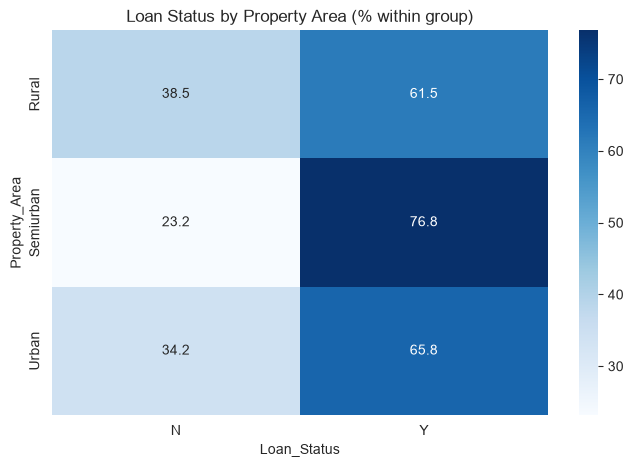

In [13]:
ct_area = pd.crosstab(df_clean["Property_Area"], df_clean["Loan_Status"], normalize="index") * 100
print(ct_area.round(1))

plt.figure()
sns.heatmap(ct_area, annot=True, fmt=".1f", cmap="Blues")
plt.title("Loan Status by Property Area (% within group)")
plt.savefig("../visuals/09_crosstab_property_area.png", bbox_inches="tight")
plt.show()

### Bivariate Analysis

**14. Numerical vs Numerical – Total Income vs Loan Amount**

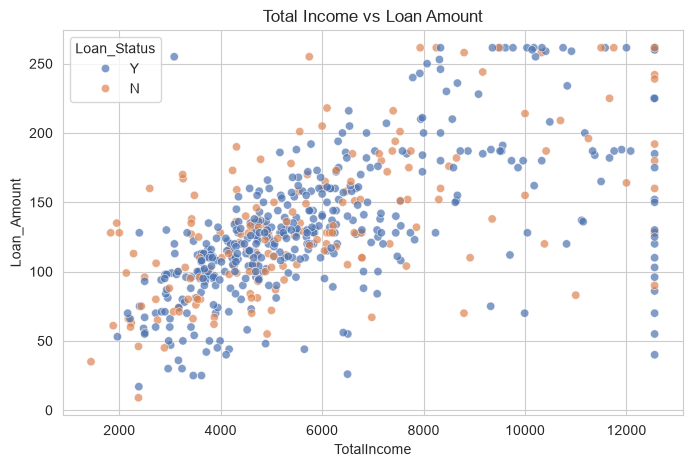

In [14]:
plt.figure()
sns.scatterplot(data=df_clean, x="TotalIncome", y="Loan_Amount", hue="Loan_Status", palette=COLORS, alpha=0.7)
plt.title("Total Income vs Loan Amount")
plt.savefig("../visuals/10_scatter_income_loanamount.png", bbox_inches="tight")
plt.show()

**15. Numerical vs Categorical – Total Income by Loan Status**

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_17784\4196073443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Loan_Status", y="TotalIncome", palette=COLORS)


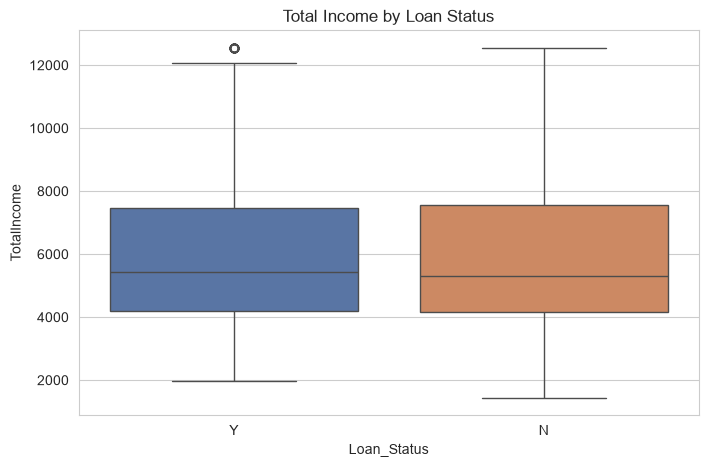

In [15]:
plt.figure()
sns.boxplot(data=df_clean, x="Loan_Status", y="TotalIncome", palette=COLORS)
plt.title("Total Income by Loan Status")
plt.savefig("../visuals/11_box_income_by_status.png", bbox_inches="tight")
plt.show()

**16. Numerical vs Categorical – Loan Amount by Education**

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_17784\1746470031.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Education", y="Loan_Amount", palette=COLORS)


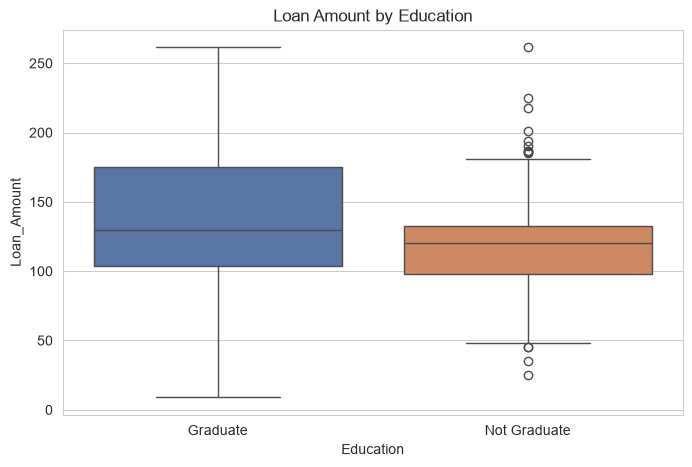

In [16]:
plt.figure()
sns.boxplot(data=df_clean, x="Education", y="Loan_Amount", palette=COLORS)
plt.title("Loan Amount by Education")
plt.savefig("../visuals/12_box_loanamount_by_education.png", bbox_inches="tight")
plt.show()

**17. Categorical vs Categorical – Married vs Loan Status**

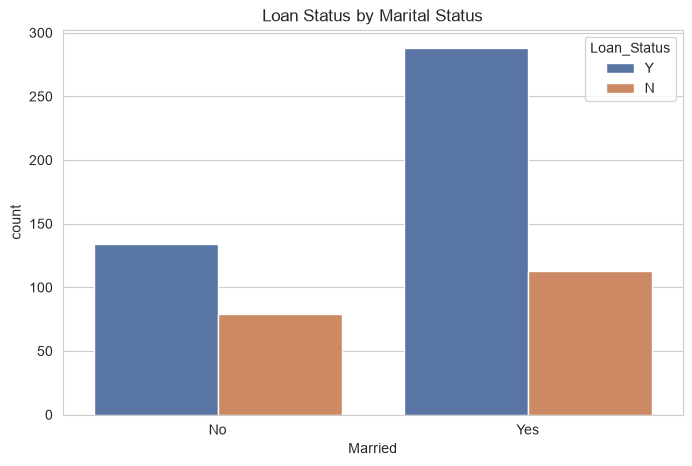

In [17]:
plt.figure()
sns.countplot(data=df_clean, x="Married", hue="Loan_Status", palette=COLORS)
plt.title("Loan Status by Marital Status")
plt.savefig("../visuals/13_married_vs_status.png", bbox_inches="tight")
plt.show()

**18. Categorical vs Categorical – Self Employed vs Loan Status**

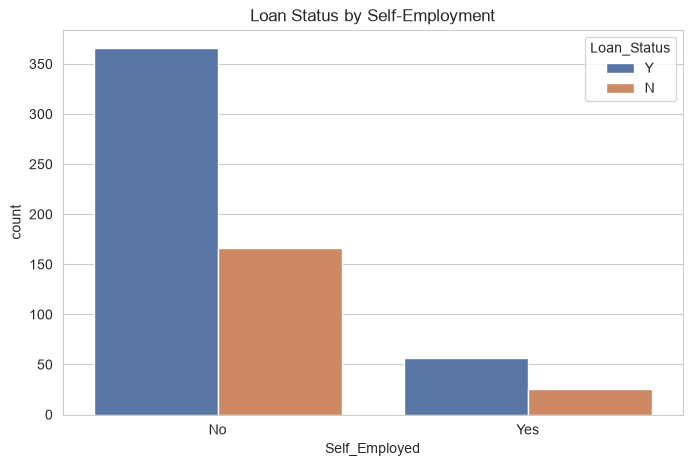

In [18]:
plt.figure()
sns.countplot(data=df_clean, x="Self_Employed", hue="Loan_Status", palette=COLORS)
plt.title("Loan Status by Self-Employment")
plt.savefig("../visuals/14_selfemployed_vs_status.png", bbox_inches="tight")
plt.show()

### Multivariate Analysis

**19. Correlation Heatmap – Numeric Features**

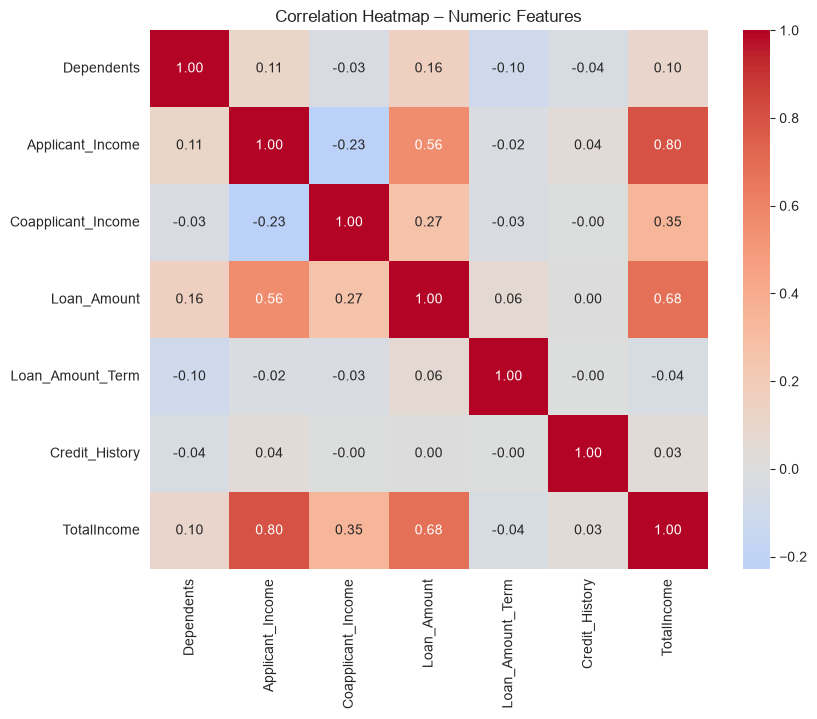

In [19]:
plt.figure(figsize=(9, 7))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Numeric Features")
plt.savefig("../visuals/15_correlation_heatmap.png", bbox_inches="tight")
plt.show()

**20. Pair Plot – Key Numeric Variables by Loan Status**

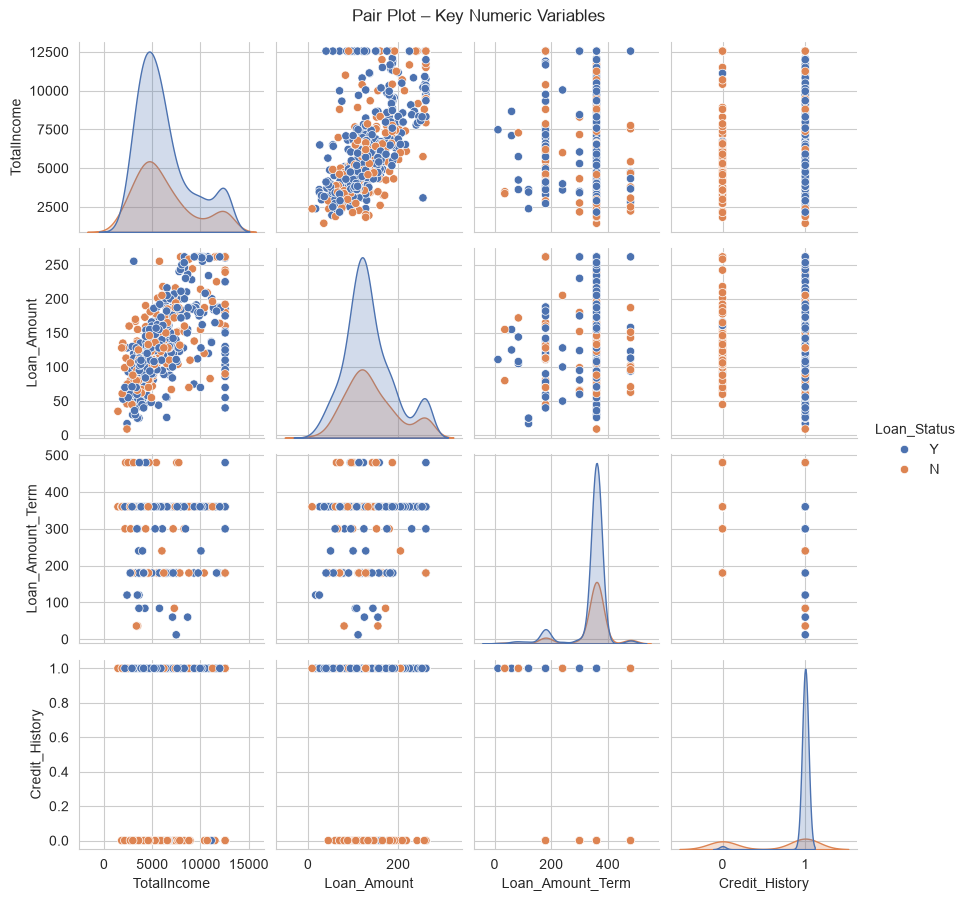

In [20]:
pair_cols = ["TotalIncome", "Loan_Amount", "Loan_Amount_Term", "Credit_History", "Loan_Status"]
g = sns.pairplot(df_clean[pair_cols], hue="Loan_Status", palette=COLORS, diag_kind="kde", height=2.2)
g.fig.suptitle("Pair Plot – Key Numeric Variables", y=1.02)
g.savefig("../visuals/16_pairplot.png", bbox_inches="tight")
plt.show()

**21. Grouped Analysis – Credit History x Property Area x Loan Status**

<Figure size 900x500 with 0 Axes>

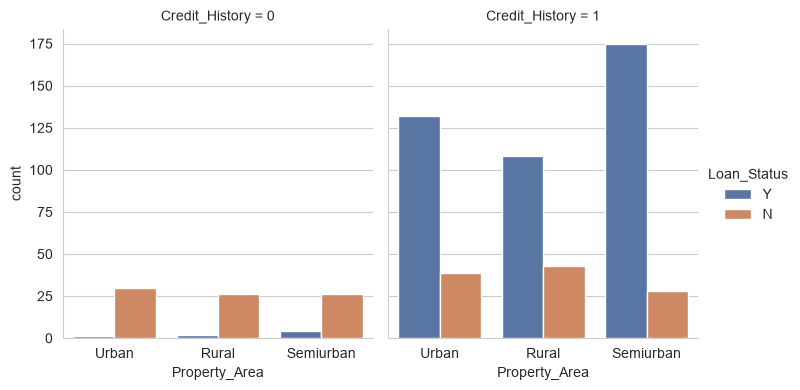

In [21]:
plt.figure(figsize=(9, 5))
sns.catplot(data=df_clean, x="Property_Area", hue="Loan_Status", col="Credit_History",
            kind="count", palette=COLORS, height=4, aspect=0.9)
plt.savefig("../visuals/17_grouped_credit_area_status.png", bbox_inches="tight")
plt.show()

**22. Class Distribution – Target Variable**

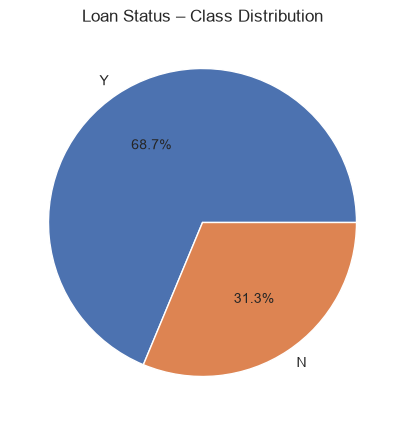

In [22]:
plt.figure()
df_clean["Loan_Status"].value_counts().plot.pie(autopct="%1.1f%%", colors=COLORS, ylabel="")
plt.title("Loan Status – Class Distribution")
plt.savefig("../visuals/18_class_distribution.png", bbox_inches="tight")
plt.show()

## Part 3 – Statistical Analysis

Five statistical tests are performed below, each with a clearly stated hypothesis, test statistic,
p-value, and business interpretation. A significance level of α = 0.05 is used throughout.


### Test 1 – Correlation Analysis: Total Income vs Loan Amount

In [23]:
r, p = stats.pearsonr(df_clean["TotalIncome"], df_clean["Loan_Amount"])
print(f"Pearson r = {r:.3f}, p-value = {p:.4g}")

Pearson r = 0.685, p-value = 3.353e-86


- **Objective:** measure the linear relationship between total household income and requested loan amount.
- **H₀:** there is no linear correlation between Total Income and Loan Amount (r = 0).
- **H₁:** there is a linear correlation between Total Income and Loan Amount (r ≠ 0).
- **Interpretation:** the correlation is positive and statistically significant (p < 0.05), but moderate in strength — higher income is associated with larger requested loans, as expected, but income alone doesn't fully determine loan size.
- **Business implication:** loan amount can't be reliably estimated from income alone; other factors (property value, purpose of the loan) likely play a role that isn't captured in this dataset.


### Test 2 – Chi-Square Test: Credit History vs Loan Status

In [24]:
contingency = pd.crosstab(df_clean["Credit_History"], df_clean["Loan_Status"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print(f"\nChi2 = {chi2:.2f}, p-value = {p:.4g}, dof = {dof}")

Loan_Status       N    Y
Credit_History          
0                82    7
1               110  415

Chi2 = 176.11, p-value = 3.418e-40, dof = 1


- **Objective:** test whether loan approval is associated with credit history.
- **H₀:** Credit_History and Loan_Status are independent.
- **H₁:** Credit_History and Loan_Status are associated.
- **Interpretation:** the p-value is far below 0.05, so we reject H₀ — there is a strong, statistically significant association between credit history and approval.
- **Business implication:** credit history should be treated as a near-mandatory screening criterion; applicants without a clean credit history are approved only in exceptional cases.


### Test 3 – Chi-Square Test: Property Area vs Loan Status

In [25]:
contingency2 = pd.crosstab(df_clean["Property_Area"], df_clean["Loan_Status"])
chi2b, pb, dofb, expectedb = stats.chi2_contingency(contingency2)
print(contingency2)
print(f"\nChi2 = {chi2b:.2f}, p-value = {pb:.4g}, dof = {dofb}")

Loan_Status     N    Y
Property_Area         
Rural          69  110
Semiurban      54  179
Urban          69  133

Chi2 = 12.30, p-value = 0.002136, dof = 2


- **Objective:** test whether loan approval is associated with the applicant's property area.
- **H₀:** Property_Area and Loan_Status are independent.
- **H₁:** Property_Area and Loan_Status are associated.
- **Interpretation:** the p-value is below 0.05, so we reject H₀ — approval rate does differ significantly by property area (Semiurban applicants are approved more often).
- **Business implication:** location-based risk assessment may be worth incorporating, though it should be checked for indirect bias against rural applicants before being used operationally.


### Test 4 – Independent T-Test: Total Income by Loan Status

In [26]:
income_approved = df_clean.loc[df_clean["Loan_Status"] == "Y", "TotalIncome"]
income_rejected = df_clean.loc[df_clean["Loan_Status"] == "N", "TotalIncome"]
t_stat, p_val = stats.ttest_ind(income_approved, income_rejected, equal_var=False)
print(f"t = {t_stat:.3f}, p-value = {p_val:.4g}")
print(f"Mean income (approved): {income_approved.mean():.0f}, Mean income (rejected): {income_rejected.mean():.0f}")

t = 0.053, p-value = 0.9576
Mean income (approved): 6199, Mean income (rejected): 6185


- **Objective:** test whether mean total income differs between approved and rejected applicants.
- **H₀:** mean Total Income is equal for approved and rejected applicants.
- **H₁:** mean Total Income differs between approved and rejected applicants.
- **Interpretation:** the p-value is above 0.05, so we fail to reject H₀ — there is no statistically significant difference in mean income between the two groups.
- **Business implication:** this is a useful (if slightly counterintuitive) finding — income alone does not meaningfully separate approved from rejected applicants, which supports the earlier observation that Credit_History matters more than income.


### Test 5 – Mann-Whitney U Test: Loan Amount by Loan Status

In [27]:
loan_approved = df_clean.loc[df_clean["Loan_Status"] == "Y", "Loan_Amount"]
loan_rejected = df_clean.loc[df_clean["Loan_Status"] == "N", "Loan_Amount"]
u_stat, p_val_u = stats.mannwhitneyu(loan_approved, loan_rejected, alternative="two-sided")
print(f"U = {u_stat:.1f}, p-value = {p_val_u:.4g}")

U = 38763.0, p-value = 0.3907


- **Objective:** test whether the distribution of requested loan amount differs between approved and rejected applicants. A non-parametric test is used here because Loan_Amount remains right-skewed even after capping.
- **H₀:** the distribution of Loan_Amount is the same for approved and rejected applicants.
- **H₁:** the distribution of Loan_Amount differs between the two groups.
- **Interpretation:** the p-value is above 0.05, so we fail to reject H₀ — loan amount alone does not significantly distinguish approved from rejected applicants.
- **Business implication:** consistent with the income finding above, the amount requested isn't, by itself, a strong driver of the approval decision — it's the applicant's credit history that dominates.


## Part 4 – Feature Engineering

Six new features are engineered below, each with its rationale, expected business value, and
expected modelling benefit.


In [28]:
df_fe = df_clean.copy()

# 1. Income Band - categorize TotalIncome into risk-relevant tiers
df_fe["Income_Band"] = pd.cut(
    df_fe["TotalIncome"], bins=[0, 3000, 6000, 10000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# 2. Debt-to-Income Ratio - loan amount relative to income (key affordability signal)
df_fe["Debt_to_Income_Ratio"] = df_fe["Loan_Amount"] / (df_fe["TotalIncome"] / 1000)

# 3. Family Size - dependents + applicant (+spouse if married)
df_fe["Family_Size"] = df_fe["Dependents"] + df_fe["Married"].map({"Yes": 1, "No": 0}) + 1

# 4. Estimated Monthly Installment (EMI)
df_fe["EMI"] = df_fe["Loan_Amount"] / df_fe["Loan_Amount_Term"]

# 5. Balance Income - income left over each month after the estimated EMI
df_fe["Balance_Income"] = (df_fe["TotalIncome"] / 12) - (df_fe["EMI"] * 1000 / 12)

# 6. Credit Risk Category - combines credit history with debt-to-income ratio
def credit_risk(row):
    if row["Credit_History"] == 0:
        return "High Risk"
    elif row["Debt_to_Income_Ratio"] > df_fe["Debt_to_Income_Ratio"].median():
        return "Medium Risk"
    else:
        return "Low Risk"

df_fe["Credit_Risk_Category"] = df_fe.apply(credit_risk, axis=1)

df_fe[["Income_Band", "Debt_to_Income_Ratio", "Family_Size", "EMI", "Balance_Income", "Credit_Risk_Category"]].head()

,Income_Band,Debt_to_Income_Ratio,Family_Size,EMI,Balance_Income,Credit_Risk_Category
0,Medium,21.884083,1,0.355556,457.787037,Low Risk
1,High,21.014612,3,0.355556,477.953704,Low Risk
2,Low,22.000000,2,0.183333,234.722222,Low Risk
3,Medium,24.286582,2,0.333333,383.972222,Medium Risk
4,Medium,23.500000,1,0.391667,467.361111,Low Risk


**23. Engineered Feature – Debt-to-Income Ratio by Loan Status**

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_17784\2503775974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x="Loan_Status", y="Debt_to_Income_Ratio", palette=COLORS)


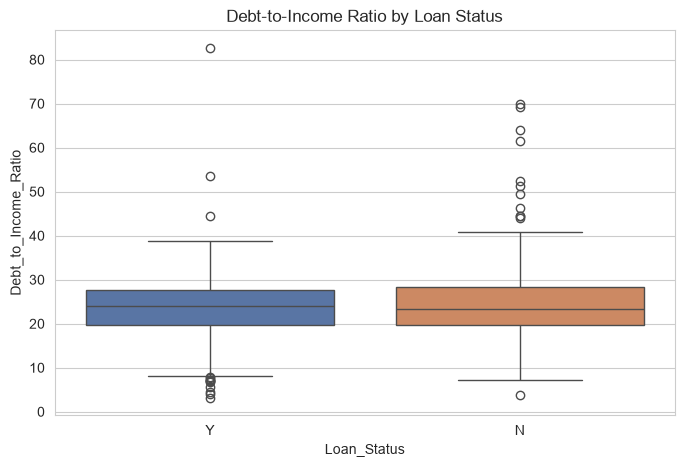

In [29]:
plt.figure()
sns.boxplot(data=df_fe, x="Loan_Status", y="Debt_to_Income_Ratio", palette=COLORS)
plt.title("Debt-to-Income Ratio by Loan Status")
plt.savefig("../visuals/19_dti_by_status.png", bbox_inches="tight")
plt.show()

**24. Engineered Feature – Credit Risk Category vs Loan Status**

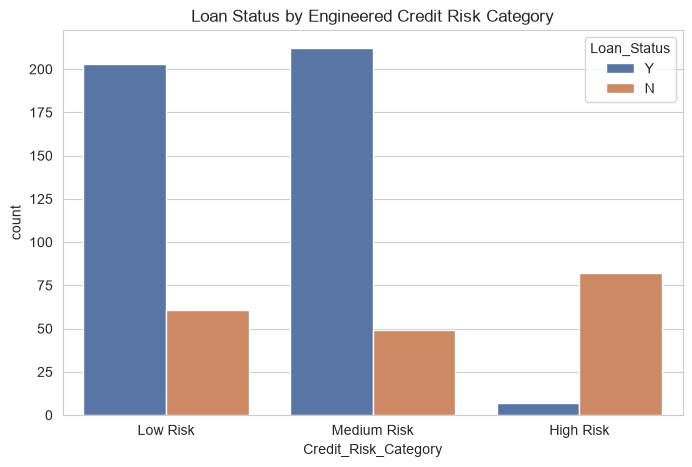

In [30]:
plt.figure()
sns.countplot(data=df_fe, x="Credit_Risk_Category", hue="Loan_Status", palette=COLORS,
              order=["Low Risk", "Medium Risk", "High Risk"])
plt.title("Loan Status by Engineered Credit Risk Category")
plt.savefig("../visuals/20_credit_risk_vs_status.png", bbox_inches="tight")
plt.show()

## Part 5 – Feature Selection

Combining the correlation analysis, the statistical tests above, and the new engineered features
to decide what goes into the final modelling dataset.


In [31]:
df_fe_encoded_check = df_fe.copy()
df_fe_encoded_check["Loan_Status_num"] = df_fe_encoded_check["Loan_Status"].map({"Y": 1, "N": 0})
numeric_check = df_fe_encoded_check.select_dtypes(include=[np.number])
corr_target = numeric_check.corr()["Loan_Status_num"].sort_values(ascending=False)
corr_target

Loan_Status_num         1.000000
Credit_History          0.540556
Family_Size             0.042963
Coapplicant_Income      0.011983
Dependents              0.010118
Balance_Income          0.004729
TotalIncome             0.002220
Applicant_Income       -0.000442
EMI                    -0.014647
Loan_Amount_Term       -0.022549
Loan_Amount            -0.047262
Debt_to_Income_Ratio   -0.103665
Name: Loan_Status_num, dtype: float64

In [32]:
df_final = df_fe.drop(columns=[
    "Applicant_Income", "Coapplicant_Income", "EMI", "Loan_Amount_Term"
])
df_final.columns.tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Loan_Amount',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'Income_Band',
 'Debt_to_Income_Ratio',
 'Family_Size',
 'Balance_Income',
 'Credit_Risk_Category']

## Part 6 – Data Preparation for Machine Learning

Saving two datasets: a final cleaned dataset (human-readable, with engineered features) and a
fully encoded/scaled machine-learning-ready dataset.


In [33]:
df_final.to_csv("../data/processed/loan_final_cleaned_w3.csv", index=False)
print("Saved: loan_final_cleaned_w3.csv", df_final.shape)

Saved: loan_final_cleaned_w3.csv (614, 15)


### Encoding

In [34]:
df_ml = df_final.copy()

label_cols = ["Gender", "Married", "Education", "Self_Employed", "Loan_Status"]
le = LabelEncoder()
for col in label_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml = pd.get_dummies(df_ml, columns=["Property_Area", "Income_Band", "Credit_Risk_Category"], drop_first=True)

df_ml.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount,Credit_History,Loan_Status,TotalIncome,Debt_to_Income_Ratio,Family_Size,Balance_Income,Property_Area_Semiurban,Property_Area_Urban,Income_Band_Medium,Income_Band_High,Income_Band_Very High,Credit_Risk_Category_Low Risk,Credit_Risk_Category_Medium Risk
0,1,0,0,0,0,128.0,1,1,5849.0,21.884083,1,457.787037,False,True,True,False,False,True,False
1,1,1,1,0,0,128.0,1,0,6091.0,21.014612,3,477.953704,False,False,False,True,False,True,False
2,1,1,0,0,1,66.0,1,1,3000.0,22.000000,2,234.722222,False,True,False,False,False,True,False
3,1,1,0,1,0,120.0,1,1,4941.0,24.286582,2,383.972222,False,True,True,False,False,False,True
4,1,0,0,0,0,141.0,1,1,6000.0,23.500000,1,467.361111,False,True,True,False,False,True,False


### Scaling

In [35]:
numeric_cols = ["TotalIncome", "Loan_Amount", "Debt_to_Income_Ratio", "Balance_Income", "Family_Size", "Dependents"]
scaler = StandardScaler()
df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols])

df_ml.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,614.0,8.175896e-01,0.386497,0.000000,1.000000,1.000000,1.000000,1.000000
Married,614.0,6.530945e-01,0.476373,0.000000,0.000000,1.000000,1.000000,1.000000
Dependents,614.0,2.893089e-18,1.000815,-0.737806,-0.737806,-0.737806,0.253470,2.236021
Education,614.0,2.182410e-01,0.413389,0.000000,0.000000,0.000000,0.000000,1.000000
Self_Employed,614.0,1.335505e-01,0.340446,0.000000,0.000000,0.000000,0.000000,1.000000
Loan_Amount,614.0,1.012581e-16,1.000815,-2.303171,-0.665939,-0.168041,0.491338,2.227252
Credit_History,614.0,8.550489e-01,0.352339,0.000000,1.000000,1.000000,1.000000,1.000000
Loan_Status,614.0,6.872964e-01,0.463973,0.000000,0.000000,1.000000,1.000000,1.000000
TotalIncome,614.0,1.996232e-16,1.000815,-1.654013,-0.706023,-0.270832,0.461824,2.213595
Debt_to_Income_Ratio,614.0,2.950951e-16,1.000815,-2.502605,-0.506885,-0.020685,0.473120,7.105330


In [36]:
df_ml.to_csv("../data/processed/loan_ml_ready_w3.csv", index=False)
print("Saved: loan_ml_ready_w3.csv", df_ml.shape)

Saved: loan_ml_ready_w3.csv (614, 19)


## Data Dictionary (Final Modelling Dataset)

| Column | Type | Description |
|---|---|---|
| Gender | binary (encoded) | Applicant gender |
| Married | binary (encoded) | Marital status |
| Dependents | numeric (scaled) | Number of dependents |
| Education | binary (encoded) | Graduate / Not Graduate |
| Self_Employed | binary (encoded) | Self-employment status |
| Credit_History | binary (0/1) | Whether credit history meets guidelines |
| Loan_Status | binary (encoded, target) | Loan approved (1) or not (0) |
| TotalIncome | numeric (scaled) | Applicant + coapplicant income |
| Loan_Amount | numeric (scaled) | Requested loan amount |
| Debt_to_Income_Ratio | numeric (scaled) | Engineered: loan amount relative to income |
| Family_Size | numeric (scaled) | Engineered: household size estimate |
| Balance_Income | numeric (scaled) | Engineered: monthly income left after estimated EMI |
| Area_Semiurban, Area_Urban | binary (one-hot) | Property area (Rural is the reference category) |
| Income_Band_* | binary (one-hot) | Engineered income tier (Low is the reference category) |
| Credit_Risk_Category_* | binary (one-hot) | Engineered risk label (Low Risk is the reference category) |

## Business Insights – Summary

- **Credit_History remains the dominant predictor** of loan approval, confirmed both visually (Week 2 and Week 3) and statistically (Chi-Square test, p < 0.001).
- **Income and loan amount, on their own, are not statistically significant drivers** of approval (T-test and Mann-Whitney test both failed to reject the null) — this was a genuinely useful and slightly surprising finding, since it means the company's approval process appears to weigh creditworthiness far more heavily than raw affordability numbers.
- **Property Area matters** — Semiurban applicants are approved significantly more often, a pattern worth investigating further for potential indirect bias.
- **Engineered features (Debt_to_Income_Ratio, Balance_Income, Credit_Risk_Category) add an affordability dimension** the raw dataset didn't directly capture, and the engineered Credit_Risk_Category visibly separates approved from rejected applicants better than any single raw feature except Credit_History.
- **Dataset limitations:** the sample size (614 applications) is modest, and some engineered ratios (EMI, Debt_to_Income_Ratio) rely on an assumed loan term that may not reflect real repayment schedules. The class imbalance (69/31) should be considered when selecting a model and evaluation metric in Week 4.
- **Next steps:** the final dataset is ready for baseline model training in Week 4 — logistic regression as an interpretable baseline, and a tree-based model (e.g. Random Forest) to better capture non-linear interactions between Credit_History, Debt_to_Income_Ratio, and Property_Area.
